# EDA on precipitation

I'm going to implement a feature naming convention now: 
 Feature naming convention for this project:

     {source}_{variable}_{operation}_{window}

 - source:    where the data came from (coc, usgs, beach, season, etc.)

 - variable:  what's being measured (precip, temp, wind, etc.)

 - operation: how it was aggregated (sum, max, mean, count, lag)
 
 - window:    over what time period (24h, 7d, 6h)

 Examples:

   coc_precip_sum_24h     -> sum of COC precip over 24h before sample

   coc_precip_max_6h      -> max single-bucket COC precip in last 6h

   usgs_precip_sum_7d     -> sum of USGS precip over 7 days

   season_sin_doy         -> sin of day-of-year (no source/window needed)

 Rule: if you change ONE thing about a feature, only ONE slot in the
 name should change. This makes filtering by prefix easy.

In [2]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt

In [3]:
load_prepared_datapath = "data/prepared_data/"
coc_precip_df = pd.read_parquet(load_prepared_datapath + "COC_precip.parquet")
usgs_precip_df = pd.read_parquet(load_prepared_datapath + "usgs_precip.parquet")

In [4]:
display(coc_precip_df.dtypes)
display(usgs_precip_df)

station_name                                  object
coc_precip_lag1h                             float64
timestamp_central    datetime64[us, America/Chicago]
station_lat                                  float64
station_lon                                  float64
dtype: object

,usgs_id,usgs_mmprecip_lag5m,timestamp_central,station_name,station_lat,station_lon
0,USGS-414542087380901,0.0,2023-05-03 13:45:00-05:00,"RAIN GAGE AT HAMILTON PARK AT CHICAGO, IL",41.761667,-87.635833
1,USGS-414542087380901,0.0,2023-05-03 13:50:00-05:00,"RAIN GAGE AT HAMILTON PARK AT CHICAGO, IL",41.761667,-87.635833
2,USGS-414542087380901,0.0,2023-05-03 13:55:00-05:00,"RAIN GAGE AT HAMILTON PARK AT CHICAGO, IL",41.761667,-87.635833
3,USGS-414542087380901,0.0,2023-05-03 14:00:00-05:00,"RAIN GAGE AT HAMILTON PARK AT CHICAGO, IL",41.761667,-87.635833
4,USGS-414542087380901,0.0,2023-05-03 14:05:00-05:00,"RAIN GAGE AT HAMILTON PARK AT CHICAGO, IL",41.761667,-87.635833
...,...,...,...,...,...,...
1825932,USGS-420119087445101,0.0,2024-06-26 23:10:00-05:00,"RAIN GAGE AT OAKTON COLLEGE AT SKOKIE, IL",42.021944,-87.747500
1825933,USGS-420119087445101,0.0,2024-06-26 23:15:00-05:00,"RAIN GAGE AT OAKTON COLLEGE AT SKOKIE, IL",42.021944,-87.747500
1825934,USGS-420119087445101,0.0,2024-06-26 23:20:00-05:00,"RAIN GAGE AT OAKTON COLLEGE AT SKOKIE, IL",42.021944,-87.747500
1825935,USGS-420119087445101,0.0,2024-06-26 23:25:00-05:00,"RAIN GAGE AT OAKTON COLLEGE AT SKOKIE, IL",42.021944,-87.747500


Text(0.5, 0, 'Time (Central)')

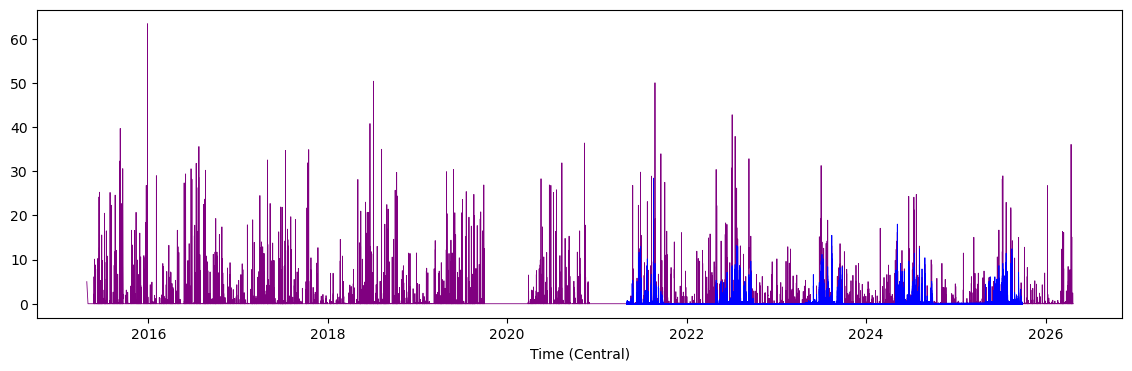

In [8]:
plot_df = (coc_precip_df
           .dropna(subset=['timestamp_central', 'coc_precip_lag1h'])
           .sort_values('timestamp_central'))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(plot_df['timestamp_central'], plot_df['coc_precip_lag1h'],
        linewidth=0.6, color='purple')
ax.plot(usgs_precip_df['timestamp_central'], usgs_precip_df['usgs_mmprecip_lag5m'],
        linewidth=0.6, color='blue')
ax.set_xlabel("Time (Central)")

Text(0.5, 0, 'Time (Central)')

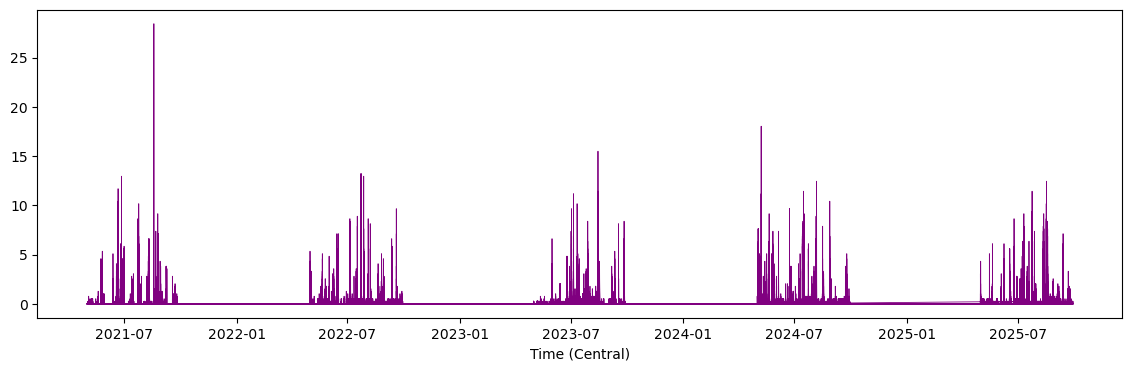

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(usgs_precip_df['timestamp_central'], usgs_precip_df['usgs_mmprecip_lag5m'],
        linewidth=0.6, color='purple')
ax.set_xlabel("Time (Central)")